✅ 2D Asset kaydedildi: C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets\42_euler_2d.png
✅ 3D Asset kaydedildi: C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets\42_euler_3d.png

--- Grafik Önizleme Hazırlanıyor ---


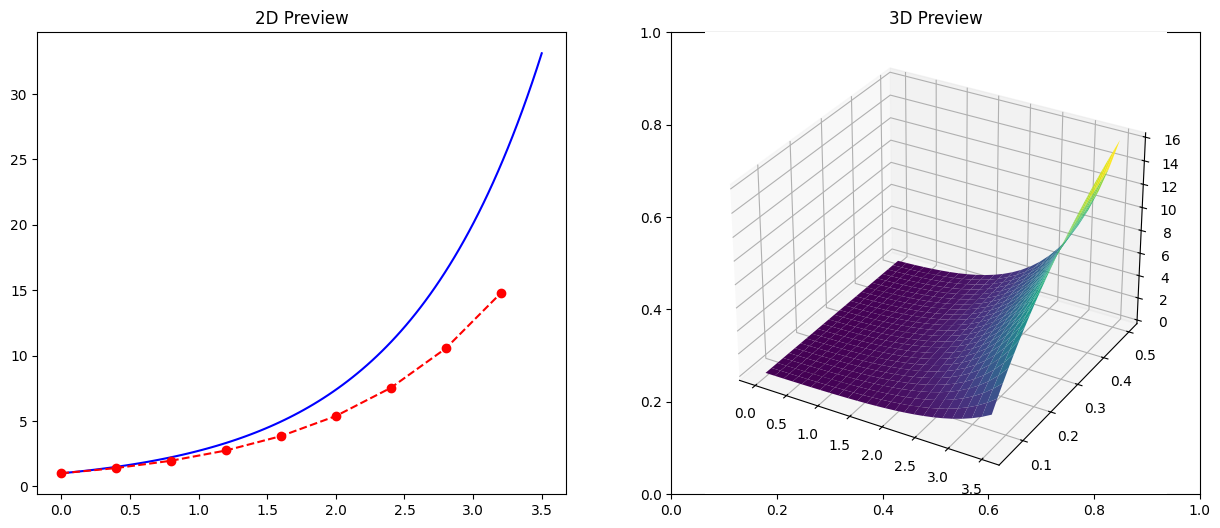

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

def run_euler_master_fixed():
    # --- YOL AYARI ---
    asset_path = r'C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Diferansiyel Denklem: dy/dx = y | y(0) = 1 (Çözüm: y = e^x)
    def f(x, y): return y
    def exact_sol(x): return np.exp(x)

    x0, y0, x_end, h = 0, 1, 3.5, 0.4 # Adımı büyük tutalım ki hatayı görelim
    
    # Euler Hesaplama
    steps = int((x_end - x0) / h)
    x_euler = np.zeros(steps + 1)
    y_euler = np.zeros(steps + 1)
    x_euler[0], y_euler[0] = x0, y0

    for i in range(steps):
        y_euler[i+1] = y_euler[i] + h * f(x_euler[i], y_euler[i])
        x_euler[i+1] = x_euler[i] + h

    # --- 📸 ASSET 1: 2D APPROXIMATION (32_euler_2d.png) ---
    fig1 = plt.figure(figsize=(10, 7))
    x_fine = np.linspace(x0, x_end, 100)
    plt.plot(x_fine, exact_sol(x_fine), 'b-', lw=2, label='Exact Solution ($e^x$)')
    plt.plot(x_euler, y_euler, 'ro--', label=f'Euler Approximation (h={h})')
    
    # Hata boşluklarını işaretle
    for i in range(len(x_euler)):
        plt.vlines(x_euler[i], y_euler[i], exact_sol(x_euler[i]), colors='gray', linestyles=':', alpha=0.5)

    plt.title("Euler Method: The Drift from Reality", fontsize=14)
    plt.xlabel("x"); plt.ylabel("y")
    plt.legend(); plt.grid(alpha=0.3)
    plt.savefig(os.path.join(asset_path, '42_euler_2d.png'), dpi=300)
    plt.close(fig1)
    print(f"✅ 2D Asset kaydedildi: {asset_path}\\42_euler_2d.png")

    # --- 📸 ASSET 2: 3D ERROR LANDSCAPE (42_euler_3d.png) ---
    # Bu kısmı tamamen bağımsız bir figürde ve açık bir subplot ile tanımlıyoruz
    fig2 = plt.figure(figsize=(12, 9))
    ax3d = fig2.add_subplot(111, projection='3d')
    
    h_vals = np.linspace(0.05, 0.5, 25)
    x_vals = np.linspace(0, 3.5, 25)
    H, X = np.meshgrid(h_vals, x_vals)
    
    # Teorik birikimli hata yüzeyi (Global Truncation Error)
    # Euler hatası yaklaşık olarak h * (e^x - 1) / 2 mertebesindedir
    Z_error = np.abs(np.exp(X) - (1 + H)**(X/H))

    surf = ax3d.plot_surface(X, H, Z_error, cmap='viridis', alpha=0.8, edgecolor='none')
    
    ax3d.set_title("3D Euler Error Accumulation Map", fontsize=14)
    ax3d.set_xlabel('Distance from Start (x)')
    ax3d.set_ylabel('Step Size (h)')
    ax3d.set_zlabel('Absolute Error')
    fig2.colorbar(surf, ax=ax3d, shrink=0.5, aspect=5)
    
    plt.savefig(os.path.join(asset_path, '42_euler_3d.png'), dpi=300)
    plt.close(fig2)
    print(f"✅ 3D Asset kaydedildi: {asset_path}\\42_euler_3d.png")

    # --- 🖥️ DASHBOARD (Visual Confirmation) ---
    # Sadece ekranda her şeyin yolunda olduğunu görmek için
    print("\n--- Grafik Önizleme Hazırlanıyor ---")
    fig_check, (ax_check1, ax_check2) = plt.subplots(1, 2, figsize=(15, 6))
    ax_check1.plot(x_fine, exact_sol(x_fine), 'b')
    ax_check1.plot(x_euler, y_euler, 'ro--')
    ax_check1.set_title("2D Preview")
    
    ax_check2 = fig_check.add_subplot(122, projection='3d')
    ax_check2.plot_surface(X, H, Z_error, cmap='viridis')
    ax_check2.set_title("3D Preview")
    plt.show()

if __name__ == "__main__":
    run_euler_master_fixed()